# 모델 그대로 사용하기

# 1.환경준비

## (1) 라이브러리 설치

In [ ]:
# 필요한 라이브러리 설치
!pip install langchain-huggingface langchain-core huggingface_hub -q

## (2) 라이브러리 Import

In [ ]:
import pandas as pd
import numpy as np
import os
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from transformers import pipeline

# 2.Transformer 사용하기

* 영어로 테스트 할 수 있는 예제를 사용해 봅니다.

  **Pipeline 함수**
- transformer 기반 LLM 모델을 손쉽게 사용할 수 있게 해주는 함수

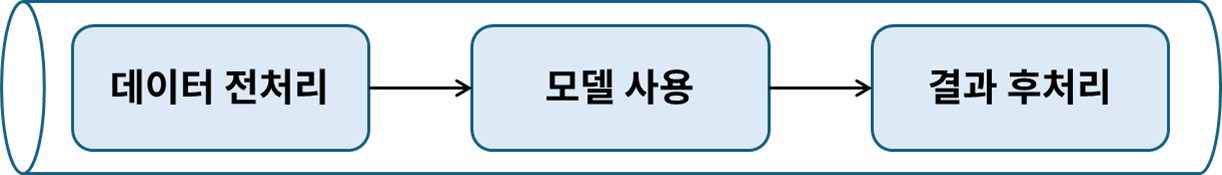


**Pipeline으로 사용 가능한 언어 관련 task**
- sentiment-analysis
- zero-shot-classification
- summarization
- translation
- text-generation
- feature-extraction
- fill-mask
- ner(개체 명 인식)
- question-answering


## (1) 감성 분석

* transformer로 생성된 감성분석 모델을 다운받아 사용해 봅시다.

In [ ]:
# sentiment-analysis 모델 파이프라인 생성
# 기본 모델 : distilbert-base-uncased-finetuned-sst-2-english

classifier = pipeline("sentiment-analysis")

In [ ]:
# 모델 사용
text = ["I've been waiting for a HuggingFace course my whole life.",
        "I hate this so much!",
        "I have a dream.",
        "She was so happy."]

classifier(text)

* 😀영어 문장을 2~3개 추가해서 긍/부정 확률을 확인해 봅시다.

## (2) Zero-shot classification

* Target 범주를 정해주고, 분류하도록 해 봅시다.

In [ ]:
# Zero-shot 분류 파이프라인 생성
classifier = pipeline(task = "zero-shot-classification", model="facebook/bart-large-mnli")

In [ ]:
# 후보 레이블 지정
candidate_labels = ["tech", "politics", "business", "finance"]

In [ ]:
# 분류하고자 하는 텍스트
text = "This is a tutorial about using transformers in natural language processing."

# 분류 수행
result = classifier(text, candidate_labels)

# 결과 출력
print(f"Labels: {result['labels']}")
print(f"Scores: {result['scores']}")

* 😀새로운 후보 레이블을 지정하고, 문장을 입력하여 분류를 시도해 봅시다.

## (3) 번역
* 한국어를 영어로 번역해 봅시다.

In [ ]:
# 한국어에서 영어로 번역하는 파이프라인 생성
translator_ko_to_en = pipeline(task = "translation", model="halee9/translation_en_ko")

In [ ]:
# 번역하고자 하는 한국어 텍스트
text_ko = "안녕하세요, 오늘 미세먼지가 무척 심하네요."

# 번역 수행
translated_text_en = translator_ko_to_en(text_ko, max_length=60)

# 번역된 영어 텍스트 출력
print(f"Translated Text (KO to EN): {translated_text_en[0]['translation_text']}")

* 😀다양한 한글 문장을 입력해서 영어로 번역해 봅시다.





# 3.API 활용하여 모델 사용하기

**API란**
- 클라이언트 프로그램에게 요청을 받아
- 서버로 전달, 서버는 요청을 처리한 후
- 결과 데이터를 API에 전달
- API가 다시 데이터를 클라이언트로 전달


## (1) LLM 사용하기1

In [ ]:
# hf key 설정
os.environ["HUGGINGFACEHUB_API_TOKEN"] = "your key"

* **openai/gpt-oss-20b**
    * OpenAI가 2025년 여름에 공개한 오픈 웨이트(open-weight) 대규모 언어 모델 중 하나
    * 약 200억(20B) 파라미터 규모의 디코더 기반 Transformer 모델
    * GPT 3.5 turbo 보다 1/10 비용에 성능은 좀 더 우수

In [ ]:
# 사용할 LLM 선언
model = "openai/gpt-oss-20b"

# HuggingFace에서 해당 모델을 불러오는 엔드포인트 지정
llm_ep = HuggingFaceEndpoint(repo_id=model, task="conversational")

# HuggingFace에서 가져온 모델을 그대로 쓰지 않고,
# LangChain에서 쉽게 쓰도록 감싸는(wrapper) 단계
llm = ChatHuggingFace(llm=llm_ep)

In [ ]:
resp = llm.invoke("오늘부터 AI Agent 공부를 시작할거야.")
print(resp.content)

* 😀실습
    * 몇가지 질문을 던지고 답변을 받아 봅시다.

## (2) LLM 사용하기2

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

In [ ]:
# 시스템 역할과 질문
prompt = ChatPromptTemplate.from_messages([
    ("system", "너는 나의 친한 친구야. 내가 하는 말에 항상 칭찬과 격려를 해줘. 항상 답변은 간결하게 해."),
    ("user",  "오늘부터 AI Agent 공부를 시작할거야.")
])

resp = llm.invoke( prompt.format_messages() )
print(resp.content)

* 😀실습
    * 역할을 부여한 후 질문하여 답변을 받아 옵시다.
        * 역할 부여 사례 : 여행 플래너, 데이터분석가, 법률가, 건강관리사 등
    * 2가지 이상 역할에 대해 실습해 봅시다.


# **4. 복습문제**

* 구글에서 발표한 gemma 3 모델을 사용해서 질의 응답을 해 봅시다.
    * "google/gemma-3-12b-it"